In [1]:
# Cell 1 — imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# load just the first 10000 rows to explore
# loading all 270k rows takes too long for exploration
df = pd.read_csv('../data/samples/mimic-iv-bhc.csv', nrows=10000)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst row - input preview:")
print(df['input'].iloc[0][:300])
print(f"\nFirst row - target preview:")
print(df['target'].iloc[0][:300])

Shape: (10000, 5)

Columns: ['note_id', 'input', 'target', 'input_tokens', 'target_tokens']

First row - input preview:
<SEX> F <SERVICE> MEDICINE <ALLERGIES> No Known Allergies / Adverse Drug Reactions <ATTENDING> ___ <CHIEF COMPLAINT> Worsening ABD distension and pain <MAJOR SURGICAL OR INVASIVE PROCEDURE> Paracentesis <HISTORY OF PRESENT ILLNESS> ___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, bioplar, 

First row - target preview:
___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, bioplar, PTSD, presented from OSH ED with worsening abd distension over past week and confusion. # Ascites - p/w worsening abd distension and discomfort for last week. likely ___ portal HTN given underlying liver disease, though no ascitic f


=== Dataset Overview ===
Total rows: 10000

Missing values:
note_id          0
input            0
target           0
input_tokens     0
target_tokens    0
dtype: int64

=== Token length distribution ===
Input tokens - mean:   2266
Input tokens - median: 2156
Input tokens - max:    10456
Input tokens - min:    88

Target tokens - mean:   565
Target tokens - median: 446
Target tokens - max:    3537
Target tokens - min:    3


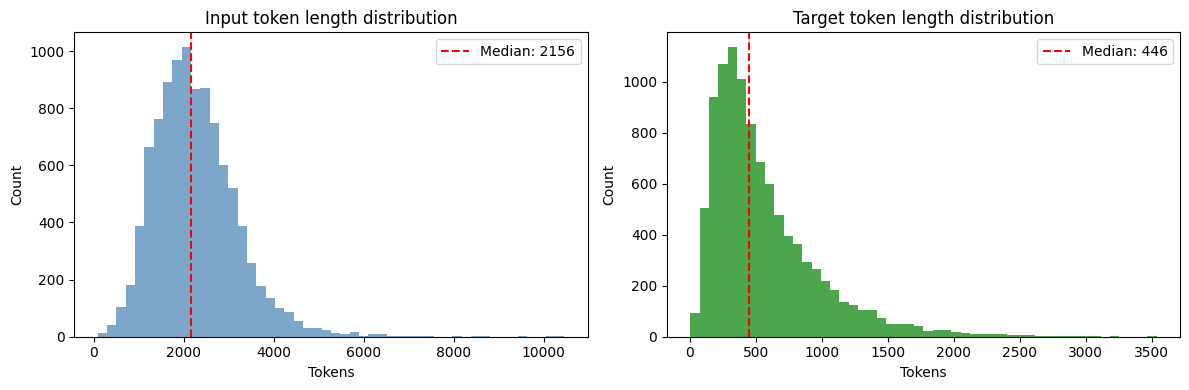


Plot saved to data/samples/token_distribution.png


In [3]:
# Cell 2 — understand the data distribution
print("=== Dataset Overview ===")
print(f"Total rows: {len(df)}")
print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\n=== Token length distribution ===")
print(f"Input tokens - mean:   {df['input_tokens'].mean():.0f}")
print(f"Input tokens - median: {df['input_tokens'].median():.0f}")
print(f"Input tokens - max:    {df['input_tokens'].max():.0f}")
print(f"Input tokens - min:    {df['input_tokens'].min():.0f}")

print(f"\nTarget tokens - mean:   {df['target_tokens'].mean():.0f}")
print(f"Target tokens - median: {df['target_tokens'].median():.0f}")
print(f"Target tokens - max:    {df['target_tokens'].max():.0f}")
print(f"Target tokens - min:    {df['target_tokens'].min():.0f}")

# plot token length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['input_tokens'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Input token length distribution')
axes[0].set_xlabel('Tokens')
axes[0].set_ylabel('Count')
axes[0].axvline(df['input_tokens'].median(), color='red', 
                linestyle='--', label=f"Median: {df['input_tokens'].median():.0f}")
axes[0].legend()

axes[1].hist(df['target_tokens'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Target token length distribution')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Count')
axes[1].axvline(df['target_tokens'].median(), color='red',
                linestyle='--', label=f"Median: {df['target_tokens'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/samples/token_distribution.png')
plt.show()
print("\nPlot saved to data/samples/token_distribution.png")


In [4]:
# Cell 3 — look at more examples to understand the data quality
print("=== Sample notes — understanding what we're working with ===\n")

for i in [0, 1, 2]:
    print(f"{'='*60}")
    print(f"EXAMPLE {i+1}")
    print(f"{'='*60}")
    print(f"INPUT ({df['input_tokens'].iloc[i]} tokens):")
    print(df['input'].iloc[i][:400])
    print(f"\nTARGET ({df['target_tokens'].iloc[i]} tokens):")
    print(df['target'].iloc[i][:400])
    print()

=== Sample notes — understanding what we're working with ===

EXAMPLE 1
INPUT (1946 tokens):
<SEX> F <SERVICE> MEDICINE <ALLERGIES> No Known Allergies / Adverse Drug Reactions <ATTENDING> ___ <CHIEF COMPLAINT> Worsening ABD distension and pain <MAJOR SURGICAL OR INVASIVE PROCEDURE> Paracentesis <HISTORY OF PRESENT ILLNESS> ___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, bioplar, PTSD, presented from OSH ED with worsening abd distension over past week. Pt reports self-discontinu

TARGET (231 tokens):
___ HCV cirrhosis c/b ascites, hiv on ART, h/o IVDU, COPD, bioplar, PTSD, presented from OSH ED with worsening abd distension over past week and confusion. # Ascites - p/w worsening abd distension and discomfort for last week. likely ___ portal HTN given underlying liver disease, though no ascitic fluid available on night of admission. No signs of heart failure noted on exam. This was ___ to med n

EXAMPLE 2
INPUT (2183 tokens):
<SEX> F <SERVICE> MEDICINE <ALLERGIES> Percocet <AT

In [5]:
# Cell 4 — prepare training data for the classifier
# 
# The classifier needs to distinguish between:
# discharge summary, lab report, radiology report, insurance EOB
#
# All MIMIC notes are discharge summaries — that gives us class 0
# We create synthetic examples for classes 1, 2, 3

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# take 2000 discharge summaries from MIMIC as class 0
discharge_texts = df['input'].iloc[:2000].tolist()
discharge_labels = [0] * 2000

print(f"Discharge summaries (class 0): {len(discharge_texts)}")
print(f"Sample: {discharge_texts[0][:150]}")

Discharge summaries (class 0): 2000
Sample: <SEX> F <SERVICE> MEDICINE <ALLERGIES> No Known Allergies / Adverse Drug Reactions <ATTENDING> ___ <CHIEF COMPLAINT> Worsening ABD distension and pain


In [6]:
# Cell 5 — create synthetic training data for classes 1, 2, 3
#
# We need examples of lab reports, radiology reports, and EOBs
# for the classifier to learn the difference
# These are synthetic but realistic in structure and vocabulary

lab_templates = [
    "LABORATORY REPORT Patient: ___ DOB: ___ COMPREHENSIVE METABOLIC PANEL Glucose: {g} mg/dL {gs} Reference: 70-99 BUN: {b} mg/dL normal Creatinine: {c} mg/dL normal Sodium: {s} mEq/L normal Potassium: {p} mEq/L normal Hemoglobin A1c: {h}% {hs} WBC: {w} K/uL normal Hemoglobin: {hb} g/dL normal Platelets: {pl} K/uL normal PROVIDER NOTE: {note}",
    "COMPLETE BLOOD COUNT AND METABOLIC PANEL Patient: ___ MRN: ___ WBC: {w} K/uL REFERENCE 4.5-11.0 RBC: {r} M/uL Hemoglobin: {hb} g/dL Hematocrit: {hct}% Platelets: {pl} K/uL Glucose: {g} mg/dL {gs} BUN: {b} mg/dL Creatinine: {c} mg/dL eGFR: {egfr} mL/min IMPRESSION: {note}",
    "LAB RESULTS Patient: ___ Ordering Provider: Dr ___ Troponin: {t} ng/mL {ts} BNP: {bnp} pg/mL {bnps} Sodium: {s} mEq/L Potassium: {p} mEq/L Chloride: {cl} mEq/L CO2: {co2} mEq/L Glucose: {g} mg/dL Creatinine: {c} mg/dL LDH: {ldh} U/L ALT: {alt} U/L AST: {ast} U/L CLINICAL NOTE: {note}",
]

radiology_templates = [
    "RADIOLOGY REPORT Exam: Chest X-Ray PA and Lateral Patient: ___ CLINICAL INDICATION: {indication} TECHNIQUE: PA and lateral chest radiographs obtained FINDINGS: Heart: {heart} Lungs: {lungs} Pleura: {pleura} Bones: {bones} IMPRESSION: {impression} RECOMMENDATION: {rec}",
    "CT SCAN REPORT Patient: ___ Exam: CT Chest with contrast INDICATION: {indication} TECHNIQUE: Axial images obtained with IV contrast FINDINGS: Mediastinum: {med} Lungs: {lungs} Pleural spaces: {pleura} Liver: {liver} Spleen: {spleen} IMPRESSION: {impression}",
    "MRI BRAIN REPORT Patient: ___ CLINICAL INDICATION: {indication} TECHNIQUE: MRI brain with and without gadolinium FINDINGS: Brain parenchyma: {brain} Ventricles: {vent} White matter: {wm} Vascular structures: {vasc} IMPRESSION: {impression} RECOMMENDATION: {rec}",
]

eob_templates = [
    "EXPLANATION OF BENEFITS Member: ___ Member ID: ___ Plan: {plan} Date of Service: ___ Provider: {provider} SERVICES RENDERED: {services} Total Billed: {total} PAYMENT SUMMARY: Billed Amount: {total} Plan Discount: {discount} Plan Paid: {paid} Member Responsibility: {member} Deductible Applied: {ded} This is NOT a bill",
    "INSURANCE EXPLANATION OF BENEFITS Claim Number: ___ Member Name: ___ Group Number: ___ Provider: {provider} Service Date: ___ PROCEDURE CODES: {codes} BILLED AMOUNT: {total} ALLOWED AMOUNT: {allowed} INSURANCE PAID: {paid} PATIENT RESPONSIBILITY: {member} CO-PAY: {copay} DEDUCTIBLE: {ded}",
    "EOB STATEMENT Member ID: ___ Plan: {plan} HEALTHCARE SERVICES: {services} CPT CODES: {codes} BILLED: {total} CONTRACTUAL ADJUSTMENT: {discount} PLAN PAYMENT: {paid} YOUR RESPONSIBILITY: {member} OUT OF POCKET MET: {oop} CONTACT MEMBER SERVICES: 1-800-555-0100",
]

import random
random.seed(42)

def generate_lab(n):
    texts = []
    for _ in range(n):
        g = random.randint(70, 300)
        texts.append(lab_templates[random.randint(0,2)].format(
            g=g, gs="HIGH" if g>99 else "normal",
            b=random.randint(7,40), c=round(random.uniform(0.6,2.5),1),
            s=random.randint(130,150), p=round(random.uniform(3.0,5.5),1),
            h=round(random.uniform(5.0,10.0),1), hs="HIGH" if random.random()>0.5 else "normal",
            w=round(random.uniform(4.0,15.0),1), hb=round(random.uniform(10.0,17.0),1),
            hct=round(random.uniform(30,52),1), pl=random.randint(100,400),
            r=round(random.uniform(3.5,6.0),2), egfr=random.randint(30,120),
            t=round(random.uniform(0.01,5.0),2), ts="HIGH" if random.random()>0.5 else "normal",
            bnp=random.randint(10,2000), bnps="HIGH" if random.random()>0.5 else "normal",
            cl=random.randint(95,110), co2=random.randint(20,30),
            ldh=random.randint(100,500), alt=random.randint(10,200),
            ast=random.randint(10,200),
            note=random.choice([
                "Values within acceptable range. Follow up in 3 months.",
                "Elevated glucose consistent with diabetes. Adjust medication.",
                "Troponin elevated. Cardiology consult recommended.",
                "Anemia noted. Iron studies ordered.",
                "Renal function stable. Continue current management."
            ])
        ))
    return texts

def generate_radiology(n):
    texts = []
    for _ in range(n):
        texts.append(radiology_templates[random.randint(0,2)].format(
            indication=random.choice(["Chest pain","Shortness of breath","Fever","Cough","Rule out pneumonia","Follow up CT","Headache","Dizziness"]),
            heart=random.choice(["Normal size","Mild cardiomegaly","Enlarged cardiac silhouette"]),
            lungs=random.choice(["Clear bilaterally","Bibasilar atelectasis","Right lower lobe opacity","No acute infiltrates"]),
            pleura=random.choice(["No effusion","Small pleural effusion","Bilateral pleural effusions"]),
            bones=random.choice(["Intact","Degenerative changes","No acute fracture"]),
            impression=random.choice(["No acute cardiopulmonary process","Pneumonia right lower lobe","Pulmonary edema","Normal study"]),
            rec=random.choice(["Clinical correlation recommended","Follow up in 6 weeks","No further imaging needed"]),
            med=random.choice(["Normal","Mild lymphadenopathy","No mass"]),
            liver=random.choice(["Normal","Hepatomegaly","Fatty infiltration"]),
            spleen=random.choice(["Normal","Splenomegaly"]),
            brain=random.choice(["Normal","No acute infarct","White matter changes"]),
            vent=random.choice(["Normal size","Mild prominence"]),
            wm=random.choice(["Normal","Mild T2 changes"]),
            vasc=random.choice(["Patent","No stenosis"])
        ))
    return texts

def generate_eob(n):
    texts = []
    for _ in range(n):
        total = random.randint(500,50000)
        discount = int(total * random.uniform(0.3,0.6))
        paid = int((total - discount) * random.uniform(0.7,0.9))
        member = total - discount - paid
        texts.append(eob_templates[random.randint(0,2)].format(
            plan=random.choice(["BlueCross PPO Gold","Aetna HMO","United Healthcare PPO","Cigna EPO"]),
            provider=random.choice(["City General Hospital","University Medical Center","Regional Health System","Community Hospital"]),
            services=random.choice(["Emergency Department Visit","Cardiac Catheterization","Inpatient Stay","Outpatient Surgery","Lab Services"]),
            codes=random.choice(["99213","99285","93510","27447","80053"]),
            total=total, discount=discount, paid=paid,
            member=member, ded=random.randint(0,1500),
            copay=random.choice([20,30,50,100]),
            allowed=total-discount,
            oop=random.randint(0,5000)
        ))
    return texts

# generate 1000 examples per class
lab_texts = generate_lab(1000)
radiology_texts = generate_radiology(1000)
eob_texts = generate_eob(1000)

lab_labels = [1] * 1000
radiology_labels = [2] * 1000
eob_labels = [3] * 1000

print(f"Class 0 - Discharge summaries: {len(discharge_texts)}")
print(f"Class 1 - Lab reports:         {len(lab_texts)}")
print(f"Class 2 - Radiology reports:   {len(radiology_texts)}")
print(f"Class 3 - Insurance EOBs:      {len(eob_texts)}")
print(f"\nTotal training examples: {len(discharge_texts)+len(lab_texts)+len(radiology_texts)+len(eob_texts)}")
print(f"\nSample lab report:")
print(lab_texts[0][:200])
print(f"\nSample radiology report:")
print(radiology_texts[0][:200])
print(f"\nSample EOB:")
print(eob_texts[0][:200])

Class 0 - Discharge summaries: 2000
Class 1 - Lab reports:         1000
Class 2 - Radiology reports:   1000
Class 3 - Insurance EOBs:      1000

Total training examples: 5000

Sample lab report:
LABORATORY REPORT Patient: ___ DOB: ___ COMPREHENSIVE METABOLIC PANEL Glucose: 233 mg/dL HIGH Reference: 70-99 BUN: 8 mg/dL normal Creatinine: 2.0 mg/dL normal Sodium: 137 mEq/L normal Potassium: 3.6 

Sample radiology report:
CT SCAN REPORT Patient: ___ Exam: CT Chest with contrast INDICATION: Fever TECHNIQUE: Axial images obtained with IV contrast FINDINGS: Mediastinum: Normal Lungs: Clear bilaterally Pleural spaces: Smal

Sample EOB:
EXPLANATION OF BENEFITS Member: ___ Member ID: ___ Plan: Cigna EPO Date of Service: ___ Provider: Community Hospital SERVICES RENDERED: Outpatient Surgery Total Billed: 41171 PAYMENT SUMMARY: Billed A


In [7]:
# Cell 6 — train the document type classifier
#
# We use TF-IDF + Logistic Regression
# TF-IDF converts text to numbers (word frequency features)
# Logistic Regression learns which words predict each doc type
# This is your original ML model

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

# combine all texts and labels
all_texts = discharge_texts + lab_texts + radiology_texts + eob_texts
all_labels = discharge_labels + lab_labels + radiology_labels + eob_labels

print(f"Total examples: {len(all_texts)}")
print(f"Label distribution: {Counter(all_labels)}")

# split into train and test sets
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    all_texts, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels  # ensure equal class distribution in both splits
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")

# step 1 — convert text to TF-IDF features
# max_features=10000 means we use top 10000 most informative words
# ngram_range=(1,2) means we use single words AND two-word phrases
print("\nFitting TF-IDF vectorizer...")
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

# step 2 — train logistic regression
print("\nTraining Logistic Regression classifier...")
classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # handles class imbalance (2000 vs 1000)
)
classifier.fit(X_train_tfidf, y_train)

# step 3 — evaluate on test set
print("\nEvaluating on test set...")
y_pred = classifier.predict(X_test_tfidf)

label_names = ['discharge', 'lab', 'radiology', 'eob']
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_names))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(f"{'':12}", end="")
for name in label_names:
    print(f"{name:12}", end="")
print()
for i, row in enumerate(cm):
    print(f"{label_names[i]:12}", end="")
    for val in row:
        print(f"{val:<12}", end="")
    print()

Total examples: 5000
Label distribution: Counter({0: 2000, 1: 1000, 2: 1000, 3: 1000})

Training set size: 4000
Test set size:     1000

Fitting TF-IDF vectorizer...
Feature matrix shape: (4000, 10000)

Training Logistic Regression classifier...

Evaluating on test set...

=== Classification Report ===
              precision    recall  f1-score   support

   discharge       1.00      1.00      1.00       400
         lab       1.00      1.00      1.00       200
   radiology       1.00      1.00      1.00       200
         eob       1.00      1.00      1.00       200

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

=== Confusion Matrix ===
            discharge   lab         radiology   eob         
discharge   400         0           0           0           
lab         0           200         0           0           
radiology   0           0           200         0    

In [8]:
# Cell 7 — save the trained model
#
# We save both the vectorizer AND the classifier
# Both are needed to make predictions on new documents
# joblib is the standard way to save sklearn models

import joblib
import os

# create models directory
os.makedirs('../data/models', exist_ok=True)

# save vectorizer
vectorizer_path = '../data/models/tfidf_vectorizer.joblib'
joblib.dump(vectorizer, vectorizer_path)
print(f"Vectorizer saved: {vectorizer_path}")

# save classifier
classifier_path = '../data/models/doc_classifier.joblib'
joblib.dump(classifier, classifier_path)
print(f"Classifier saved: {classifier_path}")

# verify they load correctly
loaded_vectorizer = joblib.load(vectorizer_path)
loaded_classifier = joblib.load(classifier_path)

# test on one example from each class
test_examples = [
    (discharge_texts[0], "discharge"),
    (lab_texts[0], "lab"),
    (radiology_texts[0], "radiology"),
    (eob_texts[0], "eob"),
]

label_names = ['discharge', 'lab', 'radiology', 'eob']

print("\n=== Verification — loading saved model and predicting ===")
for text, true_label in test_examples:
    features = loaded_vectorizer.transform([text])
    pred = loaded_classifier.predict(features)[0]
    prob = loaded_classifier.predict_proba(features)[0]
    confidence = prob[pred]
    predicted_label = label_names[pred]
    status = "CORRECT" if predicted_label == true_label else "WRONG"
    print(f"True: {true_label:<12} Predicted: {predicted_label:<12} Confidence: {confidence:.2%} [{status}]")

print("\nModel saved and verified successfully.")

Vectorizer saved: ../data/models/tfidf_vectorizer.joblib
Classifier saved: ../data/models/doc_classifier.joblib

=== Verification — loading saved model and predicting ===
True: discharge    Predicted: discharge    Confidence: 97.96% [CORRECT]
True: lab          Predicted: lab          Confidence: 98.78% [CORRECT]
True: radiology    Predicted: radiology    Confidence: 98.30% [CORRECT]
True: eob          Predicted: eob          Confidence: 98.95% [CORRECT]

Model saved and verified successfully.


In [9]:
# Cell 8 — test classifier on real sample PDFs
#
# This is the real test — does it correctly classify
# the actual PDFs we generated earlier?

import sys
sys.path.insert(0, '../src')
from medbridge.ingest.parser import extract_text_from_pdf

sample_pdfs = [
    ('../data/samples/discharge_summary.pdf', 'discharge'),
    ('../data/samples/lab_report.pdf', 'lab'),
    ('../data/samples/radiology_report.pdf', 'radiology'),
    ('../data/samples/insurance_eob.pdf', 'eob'),
]

print("=== Testing on real sample PDFs ===\n")
all_correct = True
for pdf_path, true_label in sample_pdfs:
    # extract text from PDF
    text = extract_text_from_pdf(pdf_path)
    
    # classify
    features = loaded_vectorizer.transform([text])
    pred = loaded_classifier.predict(features)[0]
    prob = loaded_classifier.predict_proba(features)[0]
    confidence = prob[pred]
    predicted_label = label_names[pred]
    status = "CORRECT" if predicted_label == true_label else "WRONG"
    if status == "WRONG":
        all_correct = False
    
    print(f"PDF:       {pdf_path.split('/')[-1]}")
    print(f"True:      {true_label}")
    print(f"Predicted: {predicted_label} ({confidence:.2%} confidence)")
    print(f"Status:    {status}")
    print()

if all_correct:
    print("All PDFs classified correctly. Classifier is ready.")
else:
    print("Some PDFs misclassified. Review above.")

=== Testing on real sample PDFs ===

PDF:       discharge_summary.pdf
True:      discharge
Predicted: discharge (80.15% confidence)
Status:    CORRECT

PDF:       lab_report.pdf
True:      lab
Predicted: lab (96.04% confidence)
Status:    CORRECT

PDF:       radiology_report.pdf
True:      radiology
Predicted: radiology (80.58% confidence)
Status:    CORRECT

PDF:       insurance_eob.pdf
True:      eob
Predicted: eob (95.60% confidence)
Status:    CORRECT

All PDFs classified correctly. Classifier is ready.
